## Assignment Task:

# Tasks:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA

In [2]:
data=pd.read_csv('ToyotaCorolla - MLR.csv')
data.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
data=data.copy()

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [5]:
data.shape

(1436, 11)

In [6]:
data.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [7]:
data.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [8]:
### Numeric Data
num_data=data._get_numeric_data()
num_data.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,90,0,2000,3,4,5,1165
1,13750,23,72937,90,0,2000,3,4,5,1165
2,13950,24,41711,90,0,2000,3,4,5,1165
3,14950,26,48000,90,0,2000,3,4,5,1165
4,13750,30,38500,90,0,2000,3,4,5,1170


# DATA VISUALIZATION

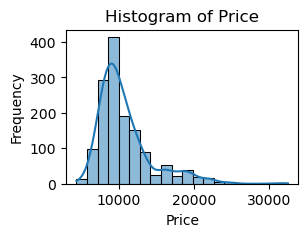

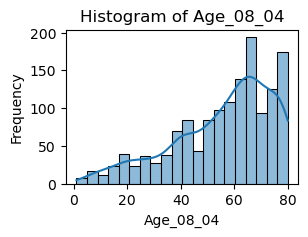

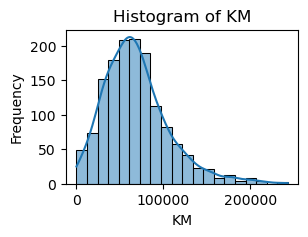

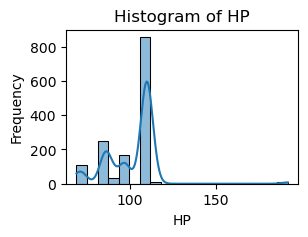

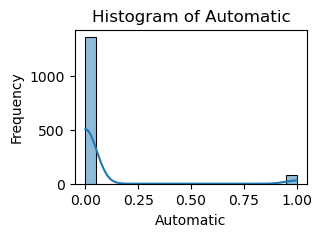

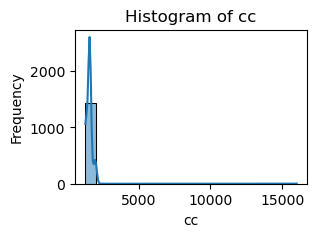

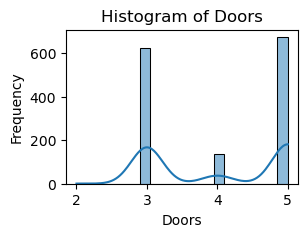

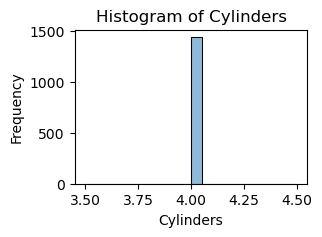

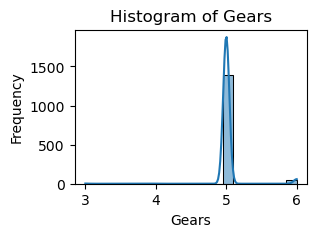

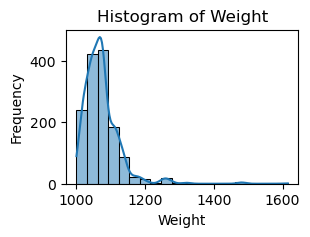

In [9]:
for col in num_data:
    plt.figure(figsize=(3,2))
    sns.histplot(data[col],kde=True,bins=20)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

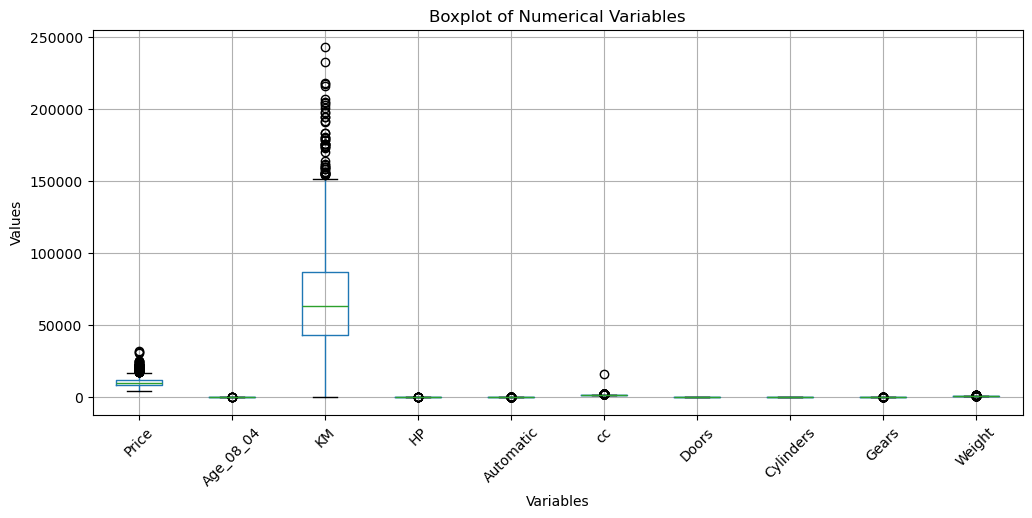

In [10]:
data.boxplot(figsize=(12,5))
plt.title("Boxplot of Numerical Variables")
plt.xlabel("Variables")
plt.ylabel("Values")
plt.xticks(rotation=45)
plt.show()

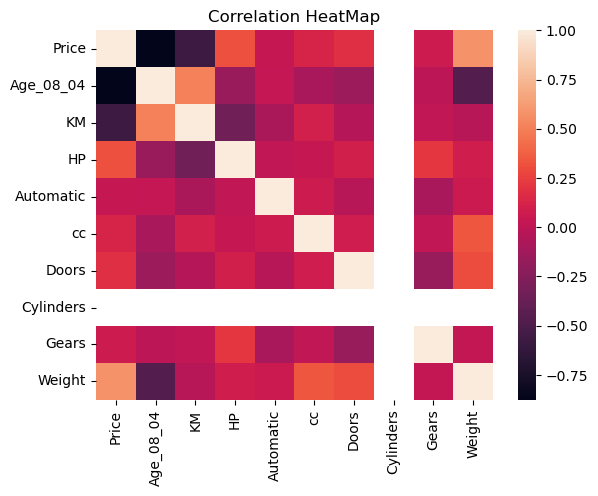

In [11]:
num_corr=num_data.corr()
sns.heatmap(num_corr)
plt.title("Correlation HeatMap")
plt.show()

# PREPROCESSING

In [12]:
df_cleaned=data.copy()

In [13]:
df_cleaned.drop_duplicates(inplace=True)

In [14]:
df_cleaned.shape

(1435, 11)

In [15]:
df_cleaned.dtypes

Price         int64
Age_08_04     int64
KM            int64
Fuel_Type    object
HP            int64
Automatic     int64
cc            int64
Doors         int64
Cylinders     int64
Gears         int64
Weight        int64
dtype: object

In [16]:
df_cleaned=pd.get_dummies(df_cleaned,columns=['Fuel_Type'],drop_first=True)

In [17]:
df_cleaned.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,True,False
1,13750,23,72937,90,0,2000,3,4,5,1165,True,False
2,13950,24,41711,90,0,2000,3,4,5,1165,True,False
3,14950,26,48000,90,0,2000,3,4,5,1165,True,False
4,13750,30,38500,90,0,2000,3,4,5,1170,True,False


In [18]:
df_cleaned.dtypes

Price               int64
Age_08_04           int64
KM                  int64
HP                  int64
Automatic           int64
cc                  int64
Doors               int64
Cylinders           int64
Gears               int64
Weight              int64
Fuel_Type_Diesel     bool
Fuel_Type_Petrol     bool
dtype: object

In [19]:
# convert Categorical values into Numerical values without using Encoding
df_cleaned=df_cleaned.astype(int)

In [20]:
df_cleaned.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,1,0
1,13750,23,72937,90,0,2000,3,4,5,1165,1,0
2,13950,24,41711,90,0,2000,3,4,5,1165,1,0
3,14950,26,48000,90,0,2000,3,4,5,1165,1,0
4,13750,30,38500,90,0,2000,3,4,5,1170,1,0


In [21]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
num_cols=df_cleaned.select_dtypes(include=['int64', 'float64']).columns
df_cleaned[num_cols]=scaler.fit_transform(df_cleaned[num_cols])
df_cleaned.head()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_Diesel,Fuel_Type_Petrol
0,0.770368,-1.777268,-0.575958,-0.767351,-0.242983,0.998113,-1.084443,0.0,-0.140475,1.774964,2.884126,-2.718789
1,0.839669,-1.777268,0.116474,-0.767351,-0.242983,0.998113,-1.084443,0.0,-0.140475,1.774964,2.884126,-2.718789
2,0.895109,-1.723380,-0.716707,-0.767351,-0.242983,0.998113,-1.084443,0.0,-0.140475,1.774964,2.884126,-2.718789
3,1.172311,-1.615603,-0.548902,-0.767351,-0.242983,0.998113,-1.084443,0.0,-0.140475,1.774964,2.884126,-2.718789
4,0.839669,-1.400049,-0.802384,-0.767351,-0.242983,0.998113,-1.084443,0.0,-0.140475,1.870688,2.884126,-2.718789


In [22]:
X=df_cleaned.drop("Price", axis=1)
y=df_cleaned["Price"]

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1148, 11), (287, 11), (1148,), (287,))

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model1=LinearRegression()
model1.fit(X_train,y_train)

LinearRegression()

In [26]:
coef1=pd.DataFrame({
    "Feature":X_train.columns,
    "Coefficient":model1.coef_
})
print("Model 1 Coefficients")
print(coef1)

Model 1 Coefficients
             Feature   Coefficient
0          Age_08_04 -6.236026e-01
1                 KM -1.661942e-01
2                 HP  6.673608e-02
3          Automatic  1.709718e-02
4                 cc -5.540083e-03
5              Doors -2.325670e-02
6          Cylinders  1.110223e-16
7              Gears  2.377671e-02
8             Weight  3.816914e-01
9   Fuel_Type_Diesel -3.343429e-02
10  Fuel_Type_Petrol  1.013875e-01


In [27]:
model2=LinearRegression()
model2.fit(X_train,y_train)

LinearRegression()

In [28]:
important_features = ["Age_08_04", "KM", "HP", "Weight"]
X2 = df_cleaned[important_features]
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, random_state=42)
model2 = LinearRegression()
model2.fit(X2_train, y_train)
coef2 = pd.DataFrame({
    "Feature": X2_train.columns,
    "Coefficient": model2.coef_
})
print("Model 2 Coefficients")
print(coef2)

Model 2 Coefficients
     Feature  Coefficient
0  Age_08_04    -0.620464
1         KM    -0.208545
2         HP     0.130681
3     Weight     0.287385


In [29]:
X3=df_cleaned.drop(["cc", "Doors"], axis=1)
X3_train, X3_test, y_train, y_test = train_test_split(X3, y, test_size=0.2, random_state=42)
model3=LinearRegression()
model3.fit(X3_train,y_train)
coef3 = pd.DataFrame({
    "Feature": X3_train.columns,
    "Coefficient": model3.coef_
})
print("Model 3 Coefficients")
print(coef3)

Model 3 Coefficients
            Feature   Coefficient
0             Price  1.000000e+00
1         Age_08_04 -1.227485e-15
2                KM -4.818221e-16
3                HP  1.821461e-15
4         Automatic  5.330246e-16
5         Cylinders  3.944305e-31
6             Gears -5.136037e-16
7            Weight -3.019884e-15
8  Fuel_Type_Diesel  1.282837e-15
9  Fuel_Type_Petrol -2.129841e-15


In [30]:
from sklearn.metrics import r2_score
print("Model 1 R2:", r2_score(y_test, model1.predict(X_test)))
print("Model 2 R2:", r2_score(y_test, model2.predict(X2_test)))
print("Model 3 R2:", r2_score(y_test, model3.predict(X3_test)))

Model 1 R2: 0.820321386996181
Model 2 R2: 0.8387549179514013
Model 3 R2: 1.0


In [31]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [32]:
yhat_train=model1.predict(X_train)

In [33]:
def eval_regression(y_train,yhat_train):
    mse=mean_squared_error(y_train,yhat_train)
    mae=mean_absolute_error(y_train,yhat_train)
    rmse=np.sqrt(mse)
    r_sq=r2_score(y_train,yhat_train)
    print('mean_Squared_Error:',mse)
    print("Mean Absolute Error (MAE):", mae)
    print('root_mean_Squared_Error:',rmse)
    print('r2_score:',r_sq)  

In [34]:
eval_regression(y_train,yhat_train)

mean_Squared_Error: 0.1319244266009121
Mean Absolute Error (MAE): 0.26610638215288257
root_mean_Squared_Error: 0.3632140231336231
r2_score: 0.8706011150336196


In [35]:
yhat_test=model1.predict(X_test)

In [36]:
def eval_regression(y_test,yhat_test):
    mse=mean_squared_error(y_test,yhat_test)
    mae=mean_absolute_error(y_test,yhat_test)
    rmse=np.sqrt(mse)
    r_sq=r2_score(y_test,yhat_test)
    print('mean_Squared_Error:',mse)
    print("Mean Absolute Error (MAE):", mae)
    print('root_mean_Squared_Error:',rmse)
    print('r2_score:',r_sq)  

In [37]:
eval_regression(y_test,yhat_test)

mean_Squared_Error: 0.1656407319066039
Mean Absolute Error (MAE): 0.27345902302603925
root_mean_Squared_Error: 0.4069898425103554
r2_score: 0.820321386996181


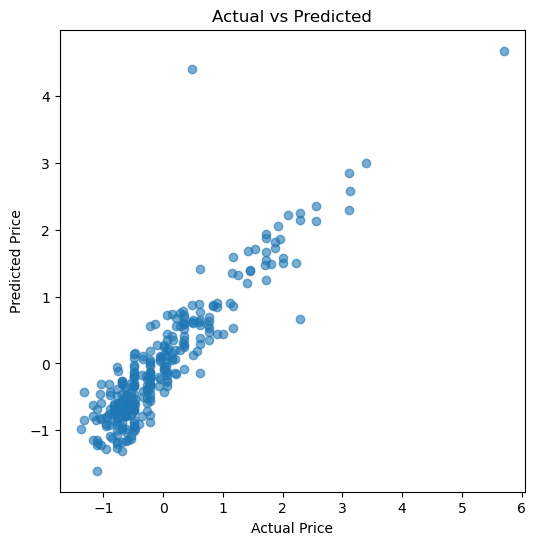

In [38]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, yhat_test,alpha=0.6)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

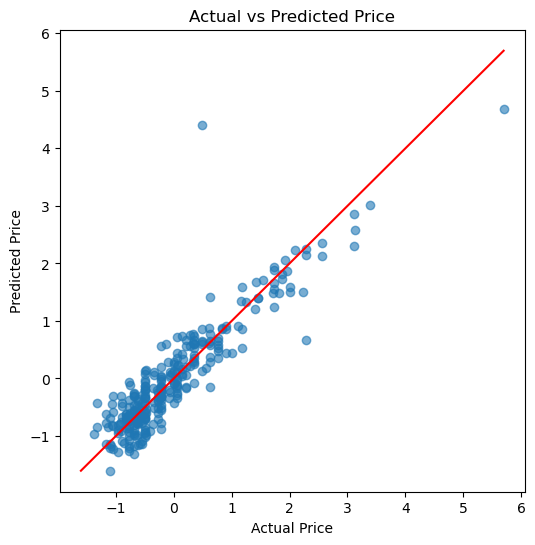

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(y_test,y=yhat_test, alpha=0.6)
min_val=min(y_test.min(), yhat_test.min())
max_val=max(y_test.max(), yhat_test.max())
plt.plot([min_val, max_val],
         [min_val, max_val],
         color='red'
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

In [40]:
from sklearn.linear_model import Lasso, Ridge

# Lasso

In [41]:
lasso=Lasso(alpha=1.0)
lasso.fit(X,y)
lasso.coef_

array([-0., -0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -0.])

In [42]:
model_params=pd.DataFrame(lasso.coef_, index=X.columns, columns=['Lasso'])
model_params

,Lasso
Age_08_04,-0.0
KM,-0.0
HP,0.0
Automatic,0.0
cc,0.0
Doors,0.0
Cylinders,0.0
Gears,0.0
Weight,0.0
Fuel_Type_Diesel,0.0


# Ridge

In [43]:
ridge=Ridge(alpha=1.0)
ridge.fit(X,y)
ridge.coef_

array([-0.6364554 , -0.18125387,  0.09680991,  0.01926068, -0.00606211,
       -0.00777357,  0.        ,  0.03279748,  0.29965813,  0.04527853,
        0.10171575])

In [44]:
model_params['Ridge']=ridge.coef_
model_params

,Lasso,Ridge
Age_08_04,-0.0,-0.636455
KM,-0.0,-0.181254
HP,0.0,0.096810
Automatic,0.0,0.019261
cc,0.0,-0.006062
Doors,0.0,-0.007774
Cylinders,0.0,0.000000
Gears,0.0,0.032797
Weight,0.0,0.299658
Fuel_Type_Diesel,0.0,0.045279


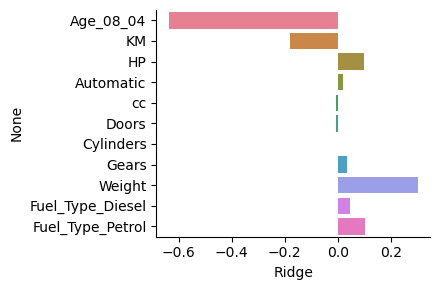

In [45]:
sns.catplot(model_params,x=model_params['Ridge'], y=model_params.index,
            kind='bar',
            hue=model_params.index,
            height=3,
            aspect = 1.5
)
plt.show()

# Conclusion